# Introduction

Healthcare costs continue to pose one of the most significant economic pressures on individuals, insurers, and society at large. Using an Insurance dataset — which captures personal attributes including age, sex, body mass index (BMI), number of children, smoking status, region, and the actual medical insurance charges billed — this project aims to build a predictive model for insurance cost (“charges”). 
'Why is this important?' you may ask, building such a model can help insurers predict policyholders expected claim amount based on their individual risk profile.

By leveraging regression techniques, the goal is two-fold: (1) understand which factors most strongly drive increasing medical insurance costs, and (2) provide a reliable cost-estimation tool that stakeholders (insurers, policy makers, individuals) can use for decision-making. Through data cleaning, exploratory data analysis, model selection, and evaluation, this work transforms raw variables into actionable insights about the financial risk embedded in health insurance.

# Importing libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset

In [3]:
insurance = pd.read_csv('insurance.csv')

## Inspecting the dataset

In [4]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
insurance.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
insurance.shape

(1338, 7)

In [9]:
insurance.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# EDA

Text(0, 0.5, 'Frequency')

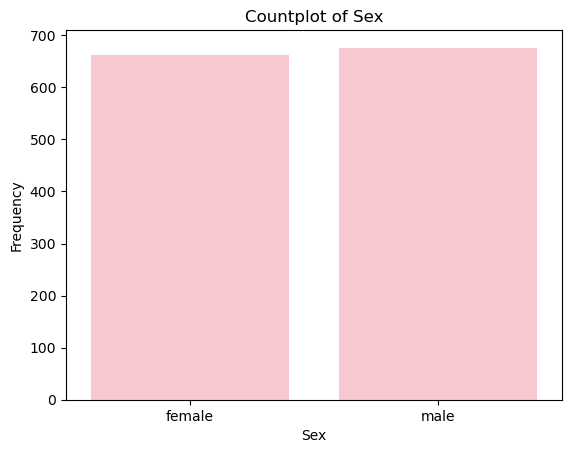

In [10]:
sns.countplot(x='sex',data=insurance, color='pink')
plt.title('Countplot of Sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

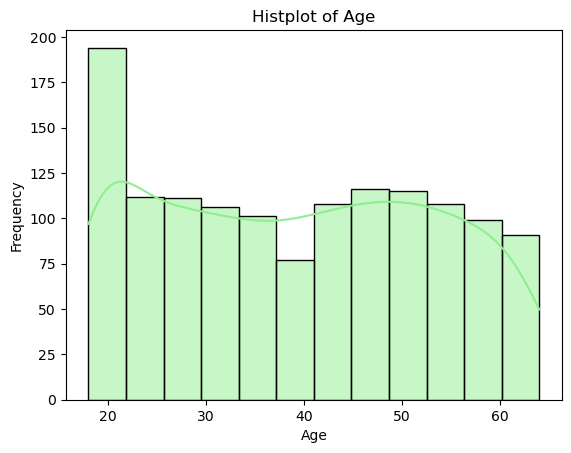

In [11]:
sns.histplot(x='age',kde=True,data=insurance, color='lightgreen')
plt.title('Histplot of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

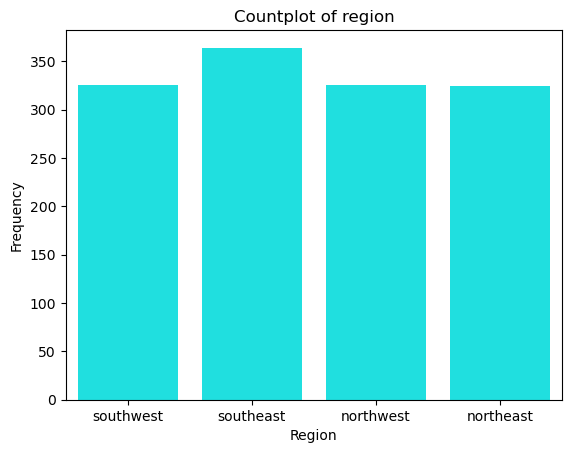

In [12]:
sns.countplot(x='region',data=insurance, color='cyan')
plt.title('Countplot of region')
plt.xlabel('Region')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

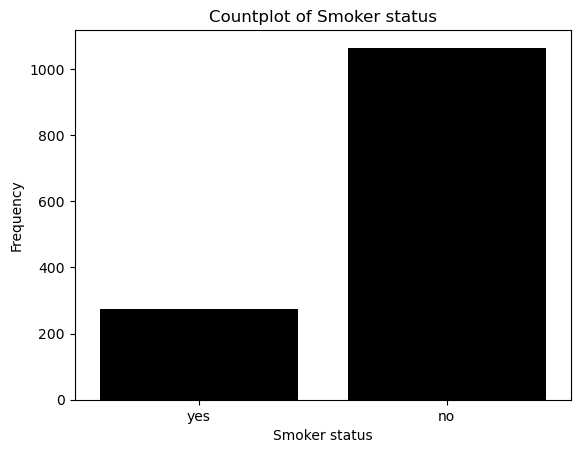

In [13]:
sns.countplot(x='smoker',data=insurance,color='black')
plt.title('Countplot of Smoker status')
plt.xlabel('Smoker status')
plt.ylabel('Frequency')

Text(37.597222222222214, 0.5, 'Charges')

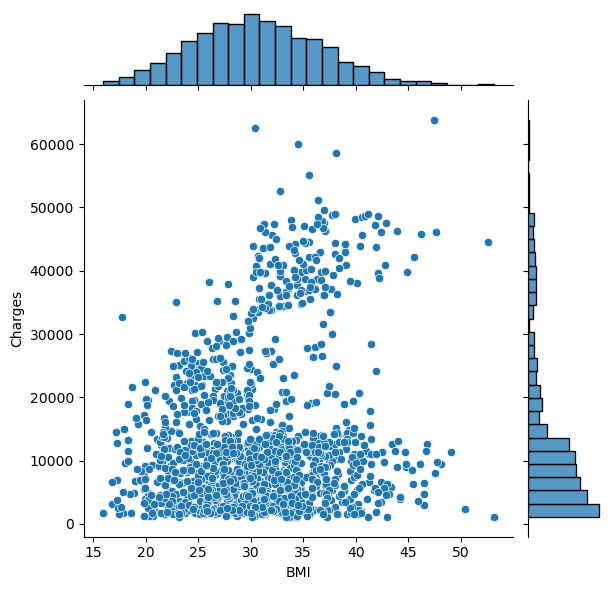

In [14]:
sns.jointplot(x='bmi',y='charges',data=insurance)
plt.xlabel('BMI')
plt.ylabel('Charges')

In [15]:
insurance = pd.get_dummies(insurance, drop_first = True).astype('int64','float64')
insurance.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [16]:
corr = insurance.corr()
corr

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,1.000000,0.108437,0.042469,0.299009,-0.020856,-0.025019,-0.000407,-0.011642,0.010016
bmi,0.108437,1.000000,0.011097,0.196188,0.046503,0.001669,-0.138495,0.271303,-0.004313
children,0.042469,0.011097,1.000000,0.067999,0.017163,0.007673,0.024806,-0.023066,0.021914
charges,0.299009,0.196188,0.067999,1.000000,0.057293,0.787251,-0.039905,0.073981,-0.043210
sex_male,-0.020856,0.046503,0.017163,0.057293,1.000000,0.076185,-0.011156,0.017117,-0.004184
smoker_yes,-0.025019,0.001669,0.007673,0.787251,0.076185,1.000000,-0.036945,0.068498,-0.036945
region_northwest,-0.000407,-0.138495,0.024806,-0.039905,-0.011156,-0.036945,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,0.271303,-0.023066,0.073981,0.017117,0.068498,-0.346265,1.000000,-0.346265
region_southwest,0.010016,-0.004313,0.021914,-0.043210,-0.004184,-0.036945,-0.320829,-0.346265,1.000000


<Axes: >

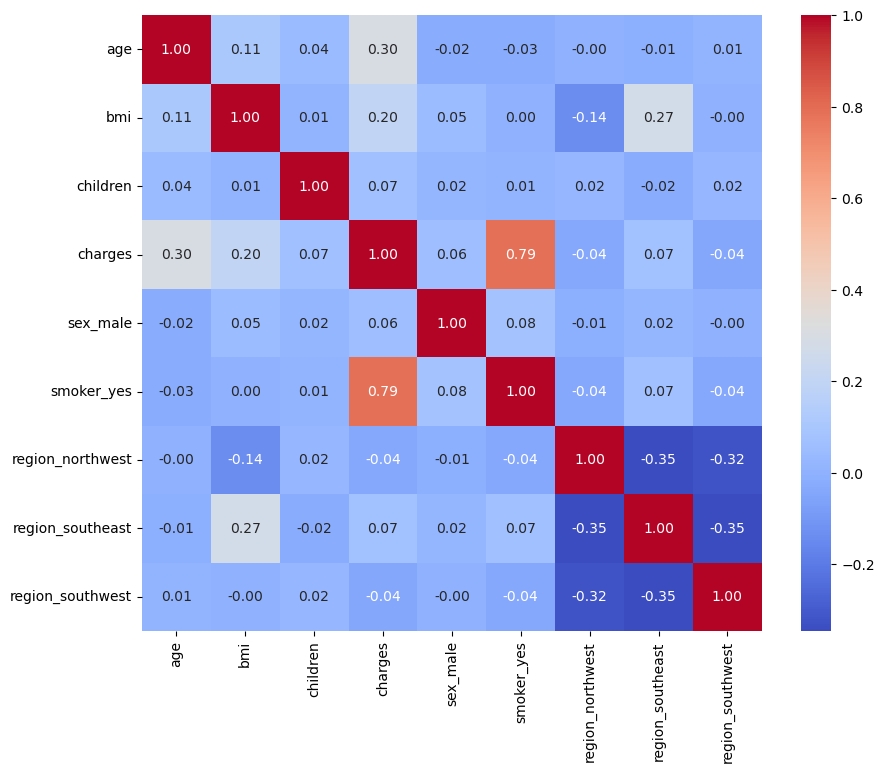

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm',annot=True,fmt='.2f')

# Linear Model

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
model = LinearRegression()

In [20]:
x = insurance.drop(columns =['charges'])
y = insurance['charges']

In [21]:
x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


In [22]:
model.fit(x,y)

LinearRegression()

In [23]:
y_pred = model.predict(x)

In [24]:
results = pd.DataFrame({'Actual':y,'Predicted':y_pred})
results.head(15)

,Actual,Predicted
0,16884,25156.523661
1,1725,3340.655590
2,4449,6866.897754
3,21984,3695.166565
4,3866,5466.132057
5,3756,3631.622900
6,8240,10668.440561
7,7281,7980.152896
8,6406,8391.943573
9,28923,11779.945638


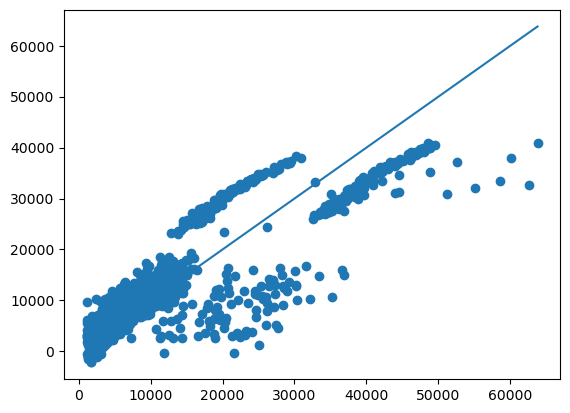

In [26]:
plt.scatter(y,y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()])

In [24]:
print(model.intercept_,model.coef_)

-11741.98785214117 [  256.97728723   337.99046325   478.23464589  -132.42092817
 23859.77137807  -346.46532467 -1042.44673308  -969.57082981]


In [25]:
mean_squared_error(y,y_pred)

36506329.651005656

In [26]:
mean_absolute_error(y,y_pred)

4170.359803898069

In [27]:
r2_score(y,y_pred)

0.7508828216439194

Text(0, 0.5, 'Freq')

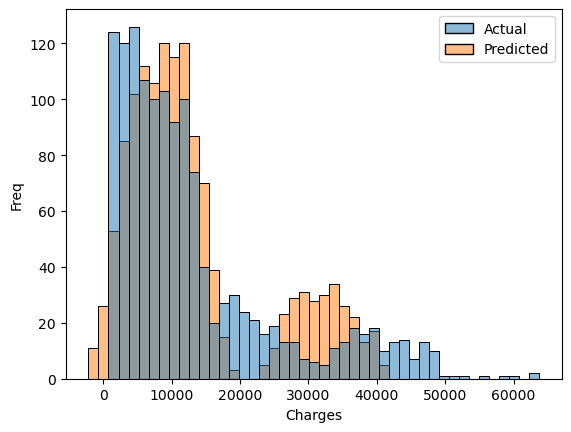

In [28]:
sns.histplot(results)
plt.xlabel('Charges')
plt.ylabel('Freq')

In [29]:
import statsmodels.api as sm

In [30]:
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()

In [31]:
print(model.pvalues)

const               9.254722e-32
age                 6.543246e-89
bmi                 7.037544e-31
children            5.366165e-04
sex_male            6.909185e-01
smoker_yes          0.000000e+00
region_northwest    4.671071e-01
region_southeast    2.967293e-02
region_southwest    4.273334e-02
dtype: float64


In [32]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.7
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        08:45:42   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04    975.287  

# Conclusion

 Conclusion

In this project, we analyzed a medical insurance dataset to understand the key factors that influence individual healthcare costs and to build predictive models for estimating insurance charges.

Through exploratory data analysis, we observed that certain variables have a significant impact on medical expenses. In particular, smoking status emerged as the strongest predictor of high charges, with smokers incurring substantially higher costs than non-smokers. Additionally, age and body mass index (BMI) were found to have a positive relationship with charges, indicating that older individuals and those with higher BMI tend to face higher medical expenses.

To quantify these relationships, we implemented machine learning models including Linear Regression and Random Forest. The models were able to capture patterns in the data and produce reasonably accurate predictions of insurance charges. While Linear Regression provided a simple and interpretable baseline, the Random Forest model demonstrated improved performance by capturing non-linear relationships in the data.

Overall, this project highlights the effectiveness of machine learning in predicting healthcare costs and identifying key risk factors. These insights can be valuable for insurance companies in pricing policies more accurately, as well as for individuals seeking to understand the drivers of their medical expenses.

Future improvements could include incorporating additional health-related variables, tuning model parameters, and exploring more advanced algorithms to further enhance predictive performance.